In [1]:
import numpy as np
import pandas as pd
import datetime
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt, numpy as np
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import AgglomerativeClustering
from matplotlib.colors import ListedColormap
from sklearn import metrics
import warnings
import sys
if not sys.warnoptions:
    warnings.simplefilter("ignore")
np.random.seed(42)

In [2]:
#loading the dataset
data = pd.read_csv("../data/marketing_campaign (2).csv", sep="\t")
print("Number of datapoints", len(data))
data.head()

Number of datapoints 2240


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
#info on features
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
#to remove the NA values 
data = data.dropna()
print("the total number of data-points after removing the rows missing values are: ", len(data))

the total number of data-points after removing the rows missing values are:  2216


In [5]:
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], dayfirst=True)
dates = []
for i in data["Dt_Customer"]:
    i = i.date()
    dates.append(i)
#dates of the newest and oldest customer 
print("The newest customer's enrolment date in the record is: ", max(dates))
print("the oldest customer's enrolment date in the records: ", min(dates))

The newest customer's enrolment date in the record is:  2014-06-29
the oldest customer's enrolment date in the records:  2012-07-30


representa há quanto tempo cada cliente está cadastrado, em relação à data mais recente do dataset.

In [6]:
#created a feature customer_for 

days = []
d1 = max(dates)
for i in dates:
    delta = d1 - i 
    days.append(delta)
data["Customer_For"] = days 
data["Customer_For"] = pd.to_numeric(data["Customer_For"], errors='coerce')

In [7]:
print("Total categories in the feature Marital_Status:\n", data["Marital_Status"].value_counts(), "\n")
print("Total categories in the feature Education:\n", data["Education"].value_counts(), "\n")

Total categories in the feature Marital_Status:
 Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64 

Total categories in the feature Education:
 Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64 



In [ ]:
#feature engineering 

#age of customer today 
data["Age"] = datetime.datetime.now().year - data["Year_Birth"]

#total spendings on various items 
data["Spent"] = data["MntWines"] + data["MntFruits"] + data["MntMeatProducts"] + data["MntFishProducts"] + data["MntSweetProducts"] + data["MntGoldProds"]

#deriving living situation by marital status alone 
data["Living_Width"] = data["Marital_Status"].replace({"Married": "Partner", "Together": "Partner", "Absurd": "Alone", "Widow": "Alone", "YOLO": "Alone", "Divorced": "Alone", "Single": "Alone"})

#Feature indicading total children living in the household 
data["Children"] = data["Kidhome"] + data["Teenhome"]

#feature for total members in the household 
data["Family_Size"] = data["Living_Width"].replace({"Alone": 1, "Partner": 2}) + data["Children"]

#Feature pertaining parenthood
data["Is_Parent"] = np.where(data["Children"] > 0, 1, 0)


#Segmenting education levels in three groups 
data["Education"] = data["Education"].replace({"basic": "Undergraduate", "2n Cycle": "Undergraduate", "Graduation": "Graduate", "Master": "Postgraduate", "Phd": "Postgraduate"})

#for clarity 
data = data.rename(columns={"MntWines": "Wines", "MntFruits": "Fruits", "MntMeatProducts": "Meat", "MntFishProducts": "Fish", "MntSweetProducts": "Sweets", "MntGoldProds": "Gold"})

#dropping some of the redundant features 
to_drop =  ["Marital_Status", "Dt_Customer" ,"Z_CostContact", "Z_Revenue", "Year_Birth", "ID"]
data = data.drop(to_drop, axis=1)


In [9]:
data.describe()

,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,...,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_For,Age,Spent,Children,Family_Size,Is_Parent
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2.216000e+03,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253,...,0.064079,0.013538,0.009477,0.150271,3.054423e+16,57.179603,607.075361,0.947202,2.592509,0.714350
std,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414,...,0.244950,0.115588,0.096907,0.357417,1.749036e+16,11.985554,602.900476,0.749062,0.905722,0.451825
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,30.000000,5.000000,0.000000,1.000000,0.000000
25%,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,1.555200e+16,49.000000,69.000000,0.000000,2.000000,0.000000
50%,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000,...,0.000000,0.000000,0.000000,0.000000,3.071520e+16,56.000000,396.500000,1.000000,3.000000,1.000000
75%,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000,...,0.000000,0.000000,0.000000,0.000000,4.570560e+16,67.000000,1048.000000,1.000000,3.000000,1.000000
max,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,6.039360e+16,133.000000,2525.000000,3.000000,5.000000,1.000000


In [10]:
import seaborn as sns

Relative Plot of some selected features: A Data Subset


<Figure size 800x550 with 0 Axes>

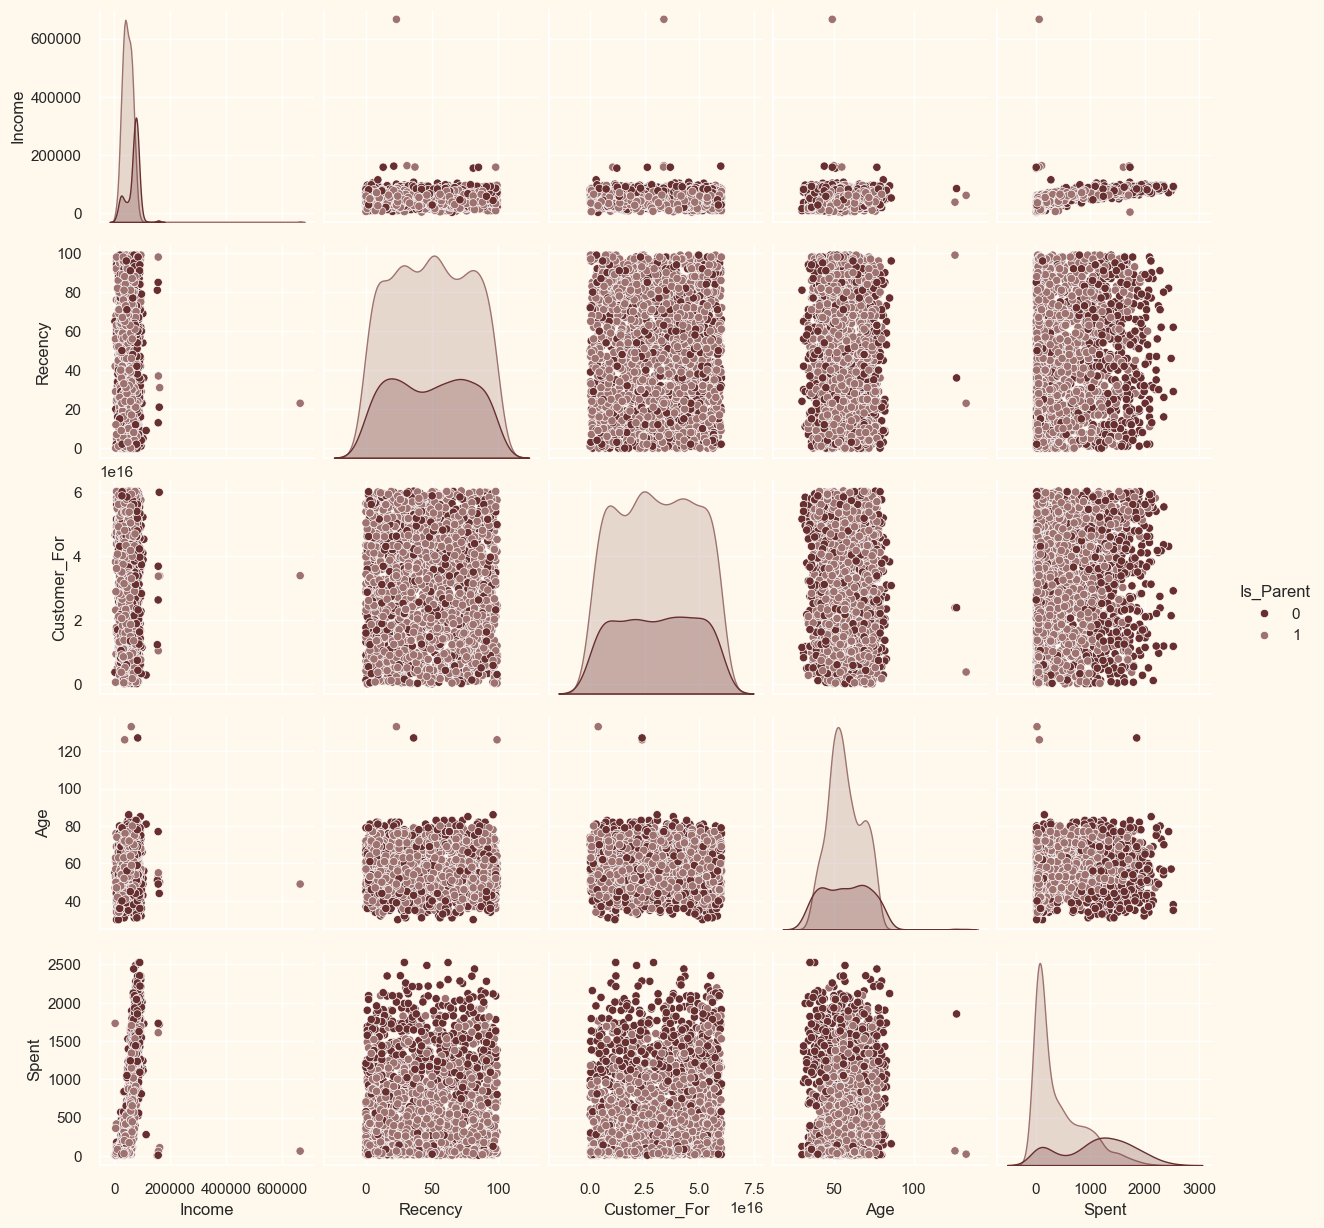

In [11]:
#to plot some selected features 
#setting up colors preferences 
sns.set(rc={"axes.facecolor": "#FFF9ED", "figure.facecolor": "#FFF9ED"})
pallet = ["#682F2F", "#9E726F", "#D9B08C", "#F2D1C9", "#F5E3DA", "#F7F4EA"]
cmap = colors.ListedColormap(["#682F2F", "#9E726F", "#D9B08C", "#F2D1C9", "#F5E3DA", "#F7F4EA"])

#ploting following features 
To_Plot = ["Income", "Recency", "Customer_For", "Age", "Spent", "Is_Parent"]
print("Relative Plot of some selected features: A Data Subset")
plt.figure()
sns.pairplot(data[To_Plot], hue= "Is_Parent", palette = (["#682F2F", "#9E726F"]))
plt.show()

In [12]:
#dropping the outliers by setting a cap on age and income
data = data[(data["Age"] <90)]
data = data[(data["Income"] <600000)]
print("The total number of data-points after removing the outliers are: ", len(data))

The total number of data-points after removing the outliers are:  2212


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2212 non-null   object 
 1   Income               2212 non-null   float64
 2   Kidhome              2212 non-null   int64  
 3   Teenhome             2212 non-null   int64  
 4   Recency              2212 non-null   int64  
 5   Wines                2212 non-null   int64  
 6   Fruits               2212 non-null   int64  
 7   Meat                 2212 non-null   int64  
 8   Fish                 2212 non-null   int64  
 9   Sweets               2212 non-null   int64  
 10  Gold                 2212 non-null   int64  
 11  NumDealsPurchases    2212 non-null   int64  
 12  NumWebPurchases      2212 non-null   int64  
 13  NumCatalogPurchases  2212 non-null   int64  
 14  NumStorePurchases    2212 non-null   int64  
 15  NumWebVisitsMonth    2212 non-null   int64 

In [14]:
#get list of categorical variables
s = (data.dtypes == 'object')
object_cols = list(s[s].index)

print("Categorical variables in the dataset:", object_cols)

Categorical variables in the dataset: ['Education', 'Living_Width']


In [15]:
#Label encoding the object dtypes 

LE = LabelEncoder()
for i in object_cols: 
    data[i] = data[[i]].apply(LE.fit_transform)

print("All features are now numerical")

All features are now numerical


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2212 non-null   int64  
 1   Income               2212 non-null   float64
 2   Kidhome              2212 non-null   int64  
 3   Teenhome             2212 non-null   int64  
 4   Recency              2212 non-null   int64  
 5   Wines                2212 non-null   int64  
 6   Fruits               2212 non-null   int64  
 7   Meat                 2212 non-null   int64  
 8   Fish                 2212 non-null   int64  
 9   Sweets               2212 non-null   int64  
 10  Gold                 2212 non-null   int64  
 11  NumDealsPurchases    2212 non-null   int64  
 12  NumWebPurchases      2212 non-null   int64  
 13  NumCatalogPurchases  2212 non-null   int64  
 14  NumStorePurchases    2212 non-null   int64  
 15  NumWebVisitsMonth    2212 non-null   int64 

In [17]:
#creating a copy of data 
ds = data.copy()

cols_del = ["AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "AcceptedCmp1", "AcceptedCmp2", "Response", "Complain"]
ds = ds.drop(cols_del, axis=1)
#Scaling 
scaler = StandardScaler()
scaler.fit(ds)
scaled_ds = pd.DataFrame(scaler.transform(ds), columns=ds.columns)
print("All features are now scaled")

All features are now scaled


In [18]:
#scaled data to be used for reducing the dimensionality 
print("Dataframe to be used for further modelling:")
scaled_ds.head()

Dataframe to be used for further modelling:


,Education,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Customer_For,Age,Spent,Living_Width,Children,Family_Size,Is_Parent
0,-0.760869,0.287105,-0.822754,-0.929699,0.310353,0.977660,1.552041,1.690293,2.453472,1.483713,...,2.503607,-0.555814,0.692181,1.527721,1.018352,1.676245,-1.349603,-1.264598,-1.758359,-1.581139
1,-0.760869,-0.260882,1.040021,0.908097,-0.380813,-0.872618,-0.637461,-0.718230,-0.651004,-0.634019,...,-0.571340,-1.171160,-0.132545,-1.189011,1.274785,-0.963297,-1.349603,1.404572,0.449070,0.632456
2,-0.760869,0.913196,-0.822754,-0.929699,-0.795514,0.357935,0.570540,-0.178542,1.339513,-0.147184,...,-0.229679,1.290224,-0.544908,-0.206048,0.334530,0.280110,0.740959,-1.264598,-0.654644,-1.581139
3,-0.760869,-1.176114,1.040021,-0.929699,-0.795514,-0.872618,-0.561961,-0.655787,-0.504911,-0.585335,...,-0.913000,-0.555814,0.279818,-1.060584,-1.289547,-0.920135,0.740959,0.069987,0.449070,0.632456
4,0.200869,0.294307,1.040021,-0.929699,1.554453,-0.392257,0.419540,-0.218684,0.152508,-0.001133,...,0.111982,0.059532,-0.132545,-0.951915,-1.033114,-0.307562,0.740959,0.069987,0.449070,0.632456


In [19]:
# Reduzir os dados para 3 componentes principais
pca = PCA(n_components=3)

# Aprender os componentes e transformar os dados escalados
pca_data = pca.fit_transform(scaled_ds)

# Criar um DataFrame com os dados transformados
PCA_ds = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2", "PC3"],
    index=scaled_ds.index
)

# Verificar as estatísticas dos componentes principais
PCA_ds.describe().T

,count,mean,std,min,25%,50%,75%,max
PC1,2212.0,5.139550e-17,2.877680,-5.966401,-2.542722,-0.772908,2.401365,7.467619
PC2,2212.0,1.284887e-17,1.708271,-4.268246,-1.316090,-0.171483,1.233686,6.207468
PC3,2212.0,7.227492e-18,1.234704,-3.425117,-0.846056,-0.063177,0.880276,6.792592


O gráfico mostra os clientes após a redução de várias características para apenas **3 componentes principais (PCA)**.

**Como interpretar:**

- **PC1, PC2 e PC3** são novas dimensões criadas pelo PCA. Cada uma combina várias variáveis originais, como renda, gastos, idade e frequência de compras.
- Cada **ponto representa um cliente**.
- Pontos próximos possuem características gerais semelhantes.
- Pontos distantes possuem perfis mais diferentes.
- A maior dispersão ocorre no **PC1**, pois ele varia aproximadamente de `-6` a `8`. Isso indica que PC1 captura a maior parte da variação dos dados.
- **PC2** e **PC3** também mostram diferenças entre os clientes, mas com menor dispersão.
- Existem regiões mais densas e alguns pontos isolados, que podem representar perfis específicos ou possíveis outliers.

A tabela confirma essa leitura:

- Existem **2.212 clientes**.
- As médias são próximas de zero porque os dados foram padronizados.
- O desvio padrão de PC1 é maior (`2,88`), indicando maior variação nessa dimensão.
- PC2 tem desvio padrão `1,71`.
- PC3 tem desvio padrão `1,23`.

**Conclusão importante:** o gráfico sugere que existem diferentes perfis de clientes, mas ele ainda não mostra grupos oficialmente. Como todos os pontos têm a mesma cor, não é possível identificar claramente os clusters. Para visualizar os segmentos, será necessário aplicar um algoritmo como `KMeans` e colorir os pontos de acordo com o cluster atribuído.

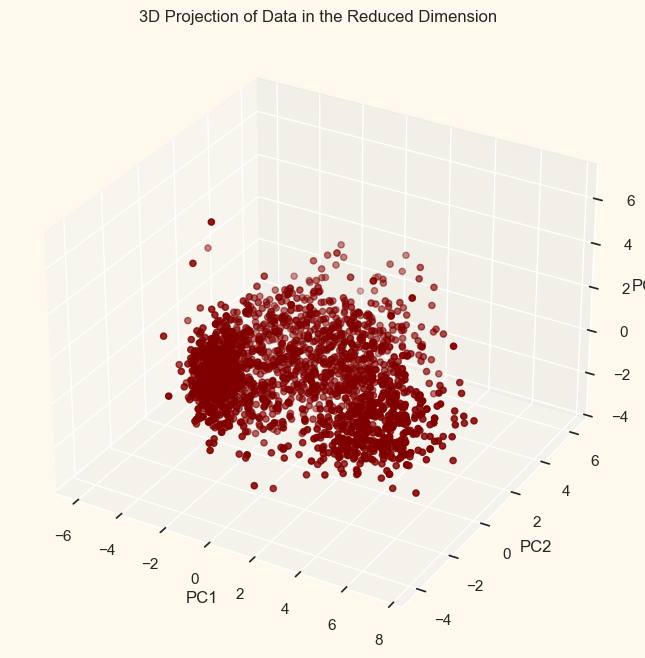

In [20]:
# ...existing code...

# Visualização 3D dos dados após redução de dimensionalidade com PCA
# Selecionar as 3 componentes principais criadas pelo PCA
x = PCA_ds["PC1"]
y = PCA_ds["PC2"]
z = PCA_ds["PC3"]

# Criar a figura 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Plotar os pontos no espaço 3D
ax.scatter(x, y, z, c="maroon", marker="o")

# Adicionar rótulos dos eixos
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

# Adicionar título
ax.set_title("3D Projection of Data in the Reduced Dimension")

# Mostrar o gráfico
plt.show()



### Interpretação do Método do Cotovelo 

> **Objetivo:** Identificar o número ideal de clusters ($K$) equilibrando a redução do erro interno com a simplicidade do modelo.

* **Linha Azul (Distortion Score):** Mede o erro/dispersão interna dos grupos. A inércia cai bruscamente de $k=2$ para $k=4$, indicando um ganho real de qualidade a cada novo cluster adicionado.
* **Linha Tracejada Preta ($k=4$):** Representa o ponto de inflexão ("cotovelo"). A partir de $k=5$, a curva se estabiliza e a redução do erro passa a ser marginal (retorno decrescente).
* **Linha Laranja (Fit Time):** Tempo de processamento em segundos para cada valor de $k$ testado.

---

**Decisão Prática:**

* **Escolha ideal:** **$K = 4$ clusters** (`score = 7557.74`).
* **Próximo passo:** Instanciar o modelo definitivo com `KMeans(n_clusters=4)` para rotular os registros do dataset.

Elbow method to determine the number of clusters to be formed: 


  File "c:\Users\leuci\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\leuci\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\leuci\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1036, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                

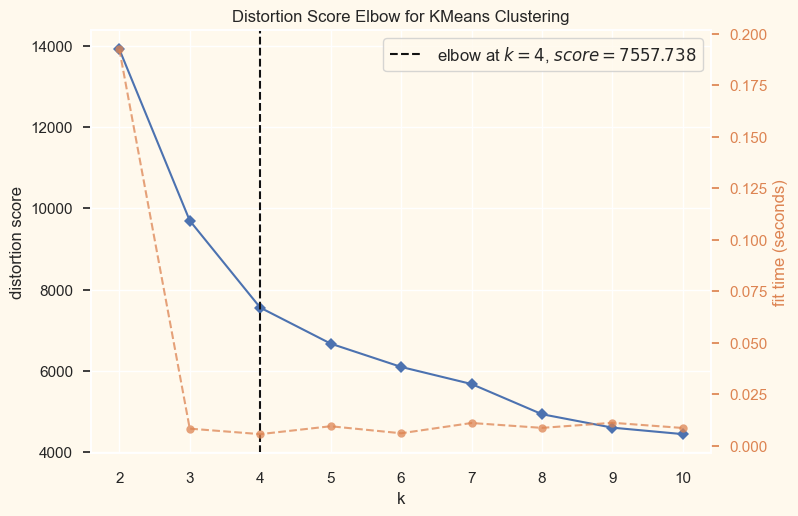

In [21]:
#quick examination of elbow method to find numbers of clusters to make 
print("Elbow method to determine the number of clusters to be formed: ")
Elbow_M = KElbowVisualizer(KMeans(), K=10)
Elbow_M.fit(PCA_ds)
Elbow_M.show();

Esse código aplica o algoritmo de **clusterização hierárquica aglomerativa** para dividir os clientes em 4 grupos.

```python
AC = AgglomerativeClustering(n_clusters=4)
```

Cria o modelo:

- `AgglomerativeClustering`: algoritmo de agrupamento hierárquico.
- `n_clusters=4`: solicita a criação de 4 clusters.
- `AC`: variável que armazena o modelo.

### Como funciona o agrupamento aglomerativo

Inicialmente, cada cliente é considerado um grupo separado. Depois, o algoritmo:

1. Calcula a distância entre os clientes.
2. Une os grupos mais próximos.
3. Continua unindo grupos semelhantes.
4. Para quando restam exatamente 4 grupos.

Esse processo forma uma hierarquia de agrupamentos. Diferentemente do K-Means, ele não começa escolhendo centros aleatórios.

```python
yhat_AC = AC.fit_predict(PCA_ds)
```

Essa linha faz duas operações:

- `fit`: analisa os dados e cria os agrupamentos.
- `predict`: atribui um número de cluster a cada cliente.

O resultado é armazenado em `yhat_AC`. Por exemplo:

```text
[2, 0, 1, 3, 2, 1, 0, ...]
```

Cada número representa o grupo de um cliente:

- `0`: cluster 0
- `1`: cluster 1
- `2`: cluster 2
- `3`: cluster 3

Os números são apenas identificadores. O cluster `3` não é necessariamente melhor que o cluster `0`.

```python
PCA_ds["Clusters"] = yhat_AC
```

Adiciona os grupos ao DataFrame que contém os componentes principais.

Antes:

| PC1 | PC2 | PC3 |
|---:|---:|---:|
| 1.2 | -0.4 | 0.8 |

Depois:

| PC1 | PC2 | PC3 | Clusters |
|---:|---:|---:|---:|
| 1.2 | -0.4 | 0.8 | 2 |

Assim, você consegue visualizar os clientes agrupados usando `PC1`, `PC2` e `PC3`.

```python
data["Clusters"] = yhat_AC
```

Adiciona o mesmo resultado ao DataFrame original `data`.

Isso é importante porque `data` contém as características reais dos clientes, como:

- renda;
- gastos;
- idade;
- número de filhos;
- compras realizadas.

Você poderá analisar o perfil de cada grupo:

```python
data.groupby("Clusters").mean(numeric_only=True)
```

Também pode verificar quantos clientes existem em cada grupo:

```python
data["Clusters"].value_counts().sort_index()
```

In [22]:
#Initiating the agglomerative Clustering model 
#Esse código aplica o algoritmo de clusterização hierárquica aglomerativa para dividir os clientes em 4 grupos.
AC = AgglomerativeClustering(n_clusters=4)

#fit model and predict clusters 
yhat_AC = AC.fit_predict(PCA_ds)
PCA_ds["Clusters"] = yhat_AC
#Adding the clusters feature to the origial dataframe 
data["Clusters"] = yhat_AC 

**Plot of Clusters:**

O gráfico 3D mostra os clientes distribuídos em três componentes principais: `PC1`, `PC2` e `PC3`. Cada ponto representa um cliente, e as cores indicam o cluster ao qual ele pertence. Pontos próximos representam clientes com características semelhantes, enquanto pontos distantes possuem perfis diferentes.

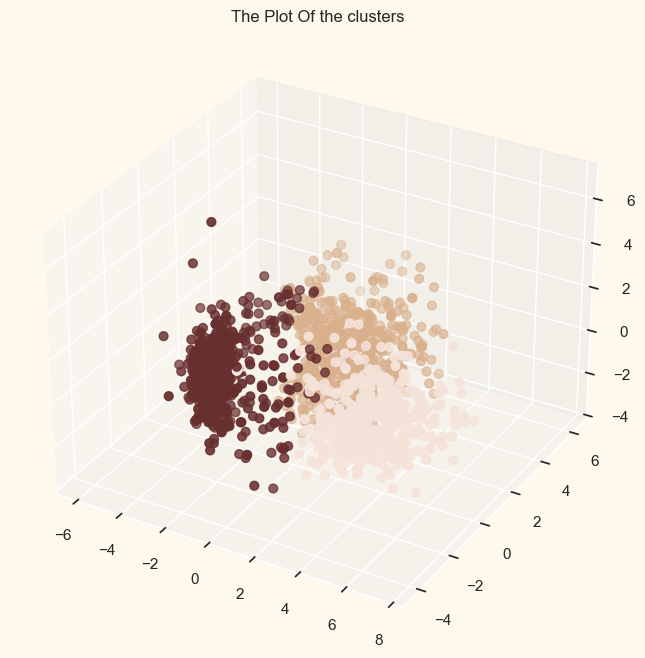

In [23]:
#Plotting the clusters 
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot(111, projection='3d', label="bla")
ax.scatter(x, y, z, s=40, c=PCA_ds["Clusters"], marker='o', cmap = cmap)
ax.set_title("The Plot Of the clusters")
plt.show();

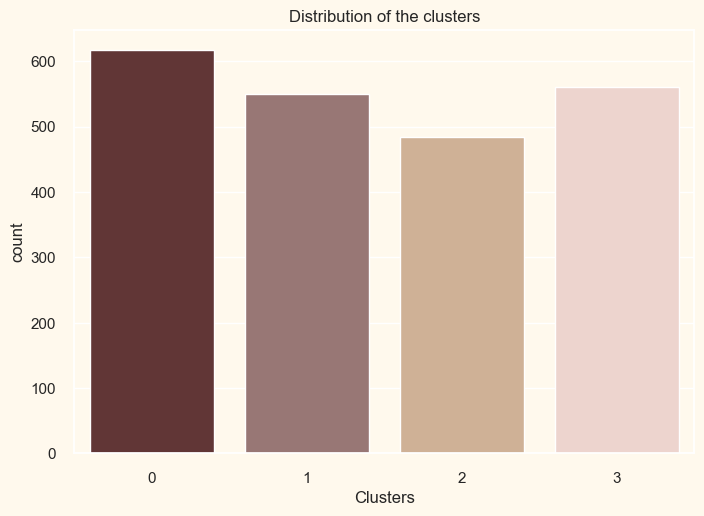

In [24]:
#Plotting countplot of clusters 
pal = ["#682F2F", "#9E726F", "#D9B08C", "#F2D1C9"]
pl = sns.countplot(x=data["Clusters"], palette= pal)
pl.set_title("Distribution of the clusters")
plt.show();


os clusters 2 e 3 possuem o perfil de clientes mais rentáveis, enquanto os clusters 0 e 1 apresentam menor renda e menor consumo.

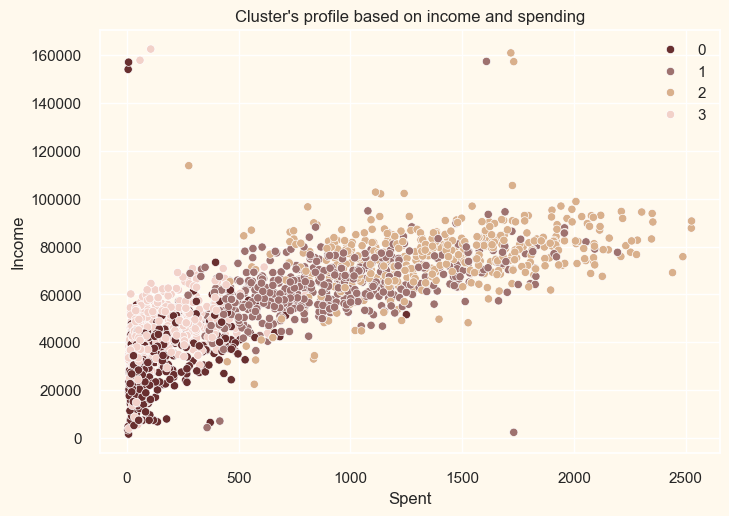

In [25]:
pl = sns.scatterplot(data = data, x= data["Spent"], y=data["Income"], hue=data["Clusters"], palette = pal)
pl.set_title("Cluster's profile based on income and spending")
plt.legend()
plt.show();



- **Eixo X:** identifica os clusters `0`, `1`, `2` e `3`.
- **Eixo Y:** mostra o valor gasto pelos clientes.
- **Caixa:** representa a maior concentração dos dados.
- **Linha dentro da caixa:** indica a mediana, ou seja, o gasto típico do grupo.
- **Linhas externas:** mostram a variação dos valores.
- **Pontos isolados:** representam possíveis outliers, clientes com gastos muito diferentes dos demais.

### Interpretação dos clusters

- **Cluster 0:** apresenta os menores gastos, geralmente próximos de zero.
- **Cluster 1:** possui gastos intermediários, maiores que o cluster 0.
- **Cluster 2:** apresenta os maiores gastos e também a maior dispersão. É o grupo de clientes que mais consome.
- **Cluster 3:** volta a apresentar gastos baixos, semelhantes ou até menores que os do cluster 0.



O **cluster 2** representa os clientes de maior valor em relação ao consumo. O **cluster 1** possui um comportamento intermediário, enquanto os **clusters 0 e 3** concentram clientes com menor gasto. Os números dos clusters são apenas identificadores e não indicam uma ordem de importância.

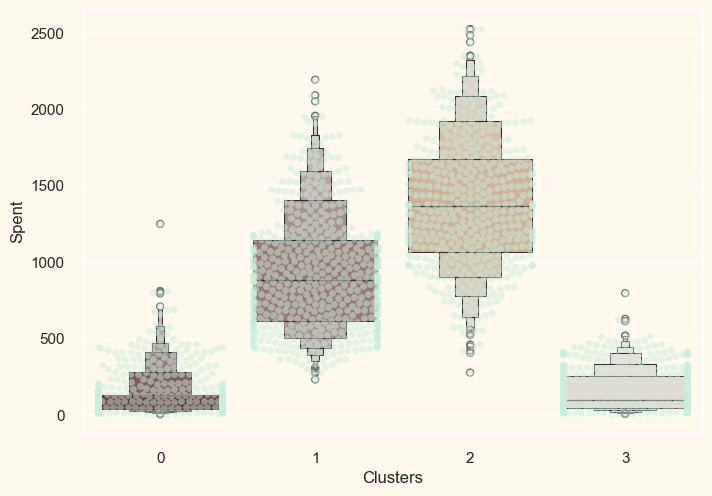

In [27]:
plt.figure()
pl = sns.swarmplot(x=data["Clusters"], y=data["Spent"], color = "#CBEDDD", alpha=0.5)
pl=sns.boxenplot(x=data["Clusters"], y=data["Spent"], palette=pal)
plt.show();

As campanhas tiveram baixa adesão geral. A empresa poderia investigar por que os clientes não estão respondendo às ofertas e criar campanhas mais personalizadas para cada cluster.

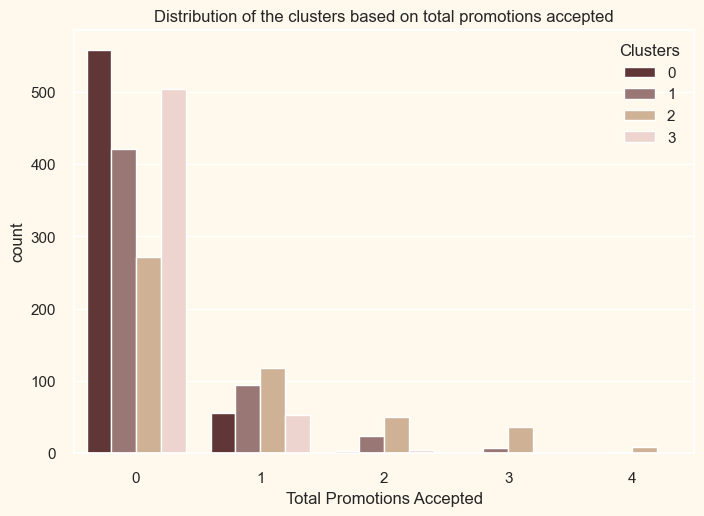

In [28]:
#creating a feature to get a sum of accepted promotions
data["Total_Promos"] = data["AcceptedCmp1"] + data["AcceptedCmp2"] + data["AcceptedCmp3"] + data["AcceptedCmp4"] + data["AcceptedCmp5"] 
plt.figure()
pl = sns.countplot(x=data["Total_Promos"], hue=data["Clusters"], palette=pal)
pl.set_title("Distribution of the clusters based on total promotions accepted")
pl.set_xlabel("Total Promotions Accepted")
plt.show();

- **Cluster 0:** a maioria realiza aproximadamente **1 a 3 compras**, com mediana próxima de 2.
- **Cluster 1:** apresenta a maior quantidade e dispersão de compras, geralmente entre **1 e 6**, com alguns clientes chegando a 13. É o grupo mais ativo em compras promocionais.
- **Cluster 2:** possui o menor número típico de compras, geralmente próximo de **1**, indicando baixa participação em ofertas.
- **Cluster 3:** apresenta comportamento intermediário, normalmente entre **1 e 4 compras**, com alguns valores mais altos.



O **cluster 1** reúne os clientes mais envolvidos com compras em promoção. O **cluster 2** demonstra menor interesse nesse tipo de compra, enquanto os clusters **0 e 3** apresentam comportamento intermediário. Os pontos isolados indicam clientes que compram muito mais ou muito menos que a maioria do próprio cluster.

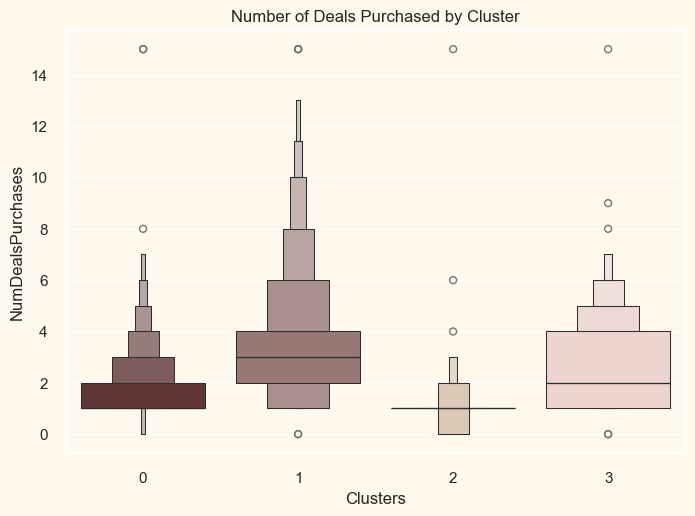

In [29]:
#Plotting the number of deals purshased 
plt.figure()
pl=sns.boxenplot(y=data["NumDealsPurchases"], x=data["Clusters"], palette=pal)
pl.set_title("Number of Deals Purchased by Cluster")
plt.show();

### `Kidhome`

Mostra a relação entre o número de crianças pequenas em casa e os gastos.

- A maior concentração está em `Kidhome = 0` ou `1`.
- Clientes com maior gasto aparecem principalmente nas regiões centrais do gráfico.
- Ter mais crianças não significa necessariamente gastar mais.
- O cluster 2 apresenta regiões de gastos elevados, mesmo concentrado próximo de poucos filhos.

### `Teenhome`

Mostra a quantidade de adolescentes na residência.

- A maioria dos clientes possui `0` ou `1` adolescente.
- O cluster 1 apresenta uma concentração relevante de gastos maiores com `Teenhome = 1`.
- O cluster 2 possui regiões de gasto mais baixo.
- Valores `2` são menos frequentes.

### `Customer_For`

Representa há quanto tempo o cliente está cadastrado.

- Os clientes estão distribuídos por vários períodos de cadastro.
- Os clusters apresentam regiões de sobreposição.
- Clientes com maior tempo de cadastro não necessariamente gastam mais.
- O cluster 2 apresenta algumas das maiores concentrações de gasto.



### `Age`

Mostra a relação entre idade e gasto.

- A maioria dos clientes está aproximadamente entre 40 e 80 anos.
- O cluster 2 possui maior concentração de clientes com gastos elevados.
- Os clientes mais jovens e mais velhos aparecem em regiões de menor gasto com mais frequência.
- Existe bastante sobreposição entre os clusters.

### `Children`

Representa o total de crianças e adolescentes na família.

- A maior parte dos clientes possui entre `0` e `2` filhos.
- Clientes com `0` ou `1` filho aparecem em praticamente todos os clusters.
- Famílias maiores não apresentam necessariamente maior gasto.
- O cluster 3 aparece mais concentrado em valores baixos de gasto.

### `Family_Size`

Representa o tamanho total da família.

- Os tamanhos mais comuns são aproximadamente de 1 a 3 pessoas.
- Famílias maiores, com 4 ou 5 membros, aparecem em menor quantidade.
- O cluster 2 apresenta concentrações de gastos mais elevados.
- O tamanho da família, sozinho, não explica completamente o valor gasto.

### `Is_Parent`

É uma variável binária:

- `0`: cliente não possui filhos;
- `1`: cliente possui filhos.

O gráfico mostra que:

- existem clientes com e sem filhos em vários clusters;
- os gastos aparecem nos dois grupos;
- ser pai ou mãe não determina sozinho o nível de consumo;
- outros fatores, como renda e perfil de compras, provavelmente têm maior influência.

### `Education`

Representa o nível de escolaridade, mas foi transformado em números pelo `LabelEncoder`.

- Os valores do eixo X são códigos, não necessariamente níveis numéricos reais.
- É possível observar diferenças de gasto entre alguns níveis educacionais.
- Os clusters 1 e 2 apresentam regiões com gastos maiores.
- Existe grande sobreposição entre os grupos.

Como `Education` é categórica, o KDE pode ser enganoso. Um gráfico de caixa ou de média por categoria seria mais adequado.

### `Living_Width`

Representa a situação familiar:

- `0`: provavelmente `Alone`;
- `1`: provavelmente `Partner`.

A maior parte dos clientes está concentrada nesses dois grupos.

- Os dois perfis aparecem em diferentes faixas de gasto.
- O cluster 2 apresenta maior concentração de gastos elevados.
- Viver sozinho ou com parceiro não determina isoladamente o consumo.

Assim como `Education`, essa variável é categórica. Portanto, um boxplot seria mais apropriado que um KDE.

Os gráficos mostram que o **gasto (`Spent`) é mais elevado principalmente no cluster 2**, enquanto os demais clusters apresentam faixas de gasto menores ou mais variadas. As variáveis pessoais ajudam a descrever os clientes, mas não explicam sozinhas o consumo. Renda, gastos anteriores e comportamento de compra parecem ser fatores mais importantes.


<Figure size 800x550 with 0 Axes>

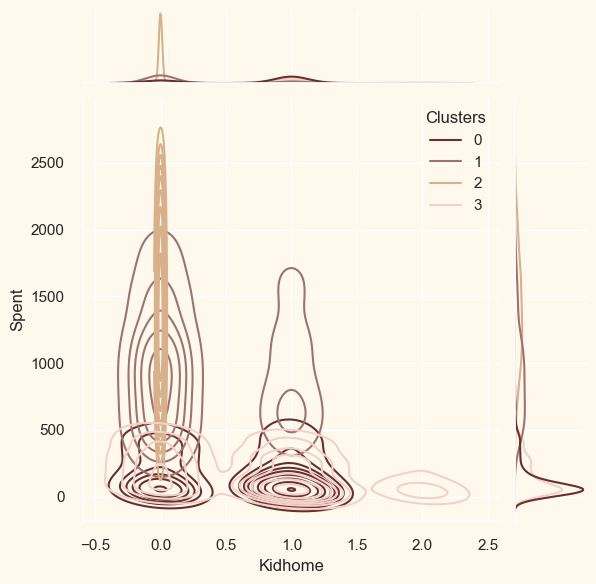

<Figure size 800x550 with 0 Axes>

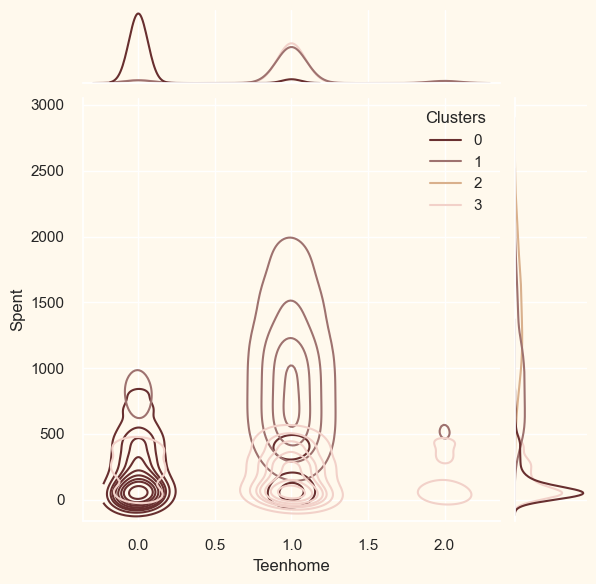

<Figure size 800x550 with 0 Axes>

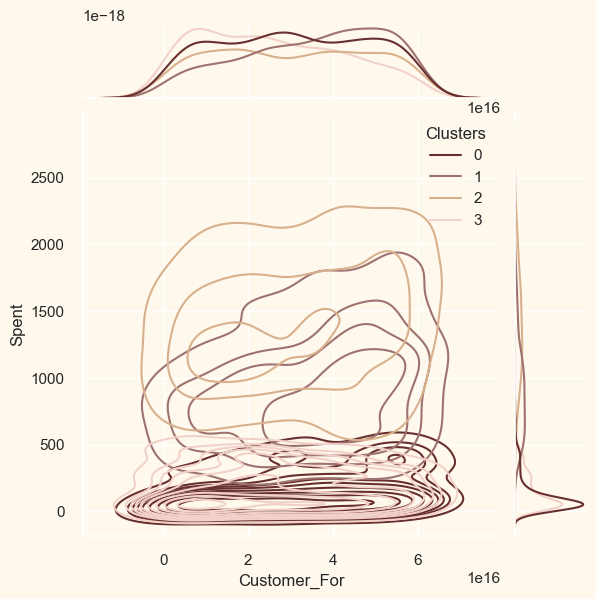

<Figure size 800x550 with 0 Axes>

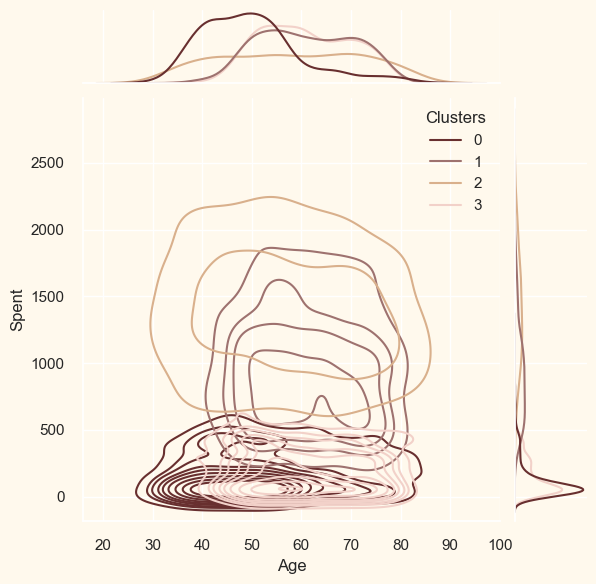

<Figure size 800x550 with 0 Axes>

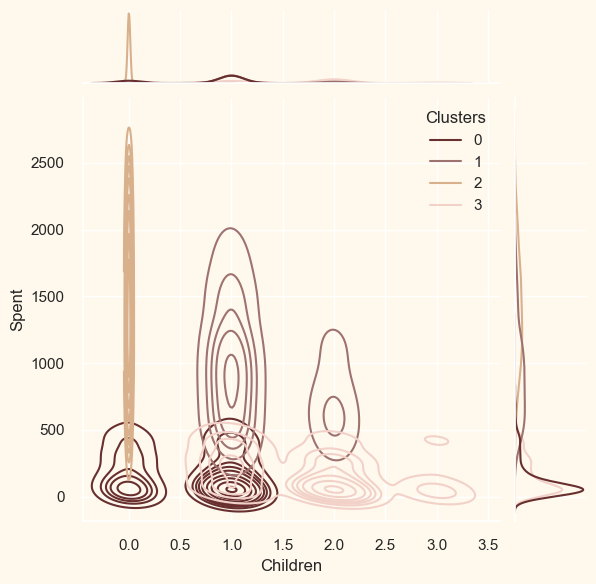

<Figure size 800x550 with 0 Axes>

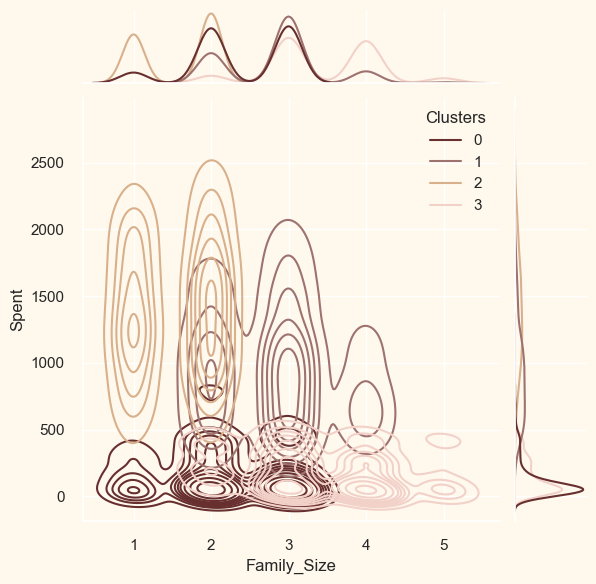

<Figure size 800x550 with 0 Axes>

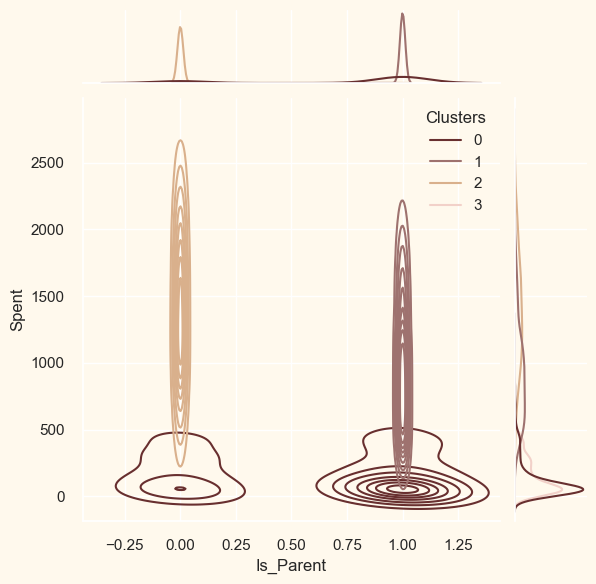

<Figure size 800x550 with 0 Axes>

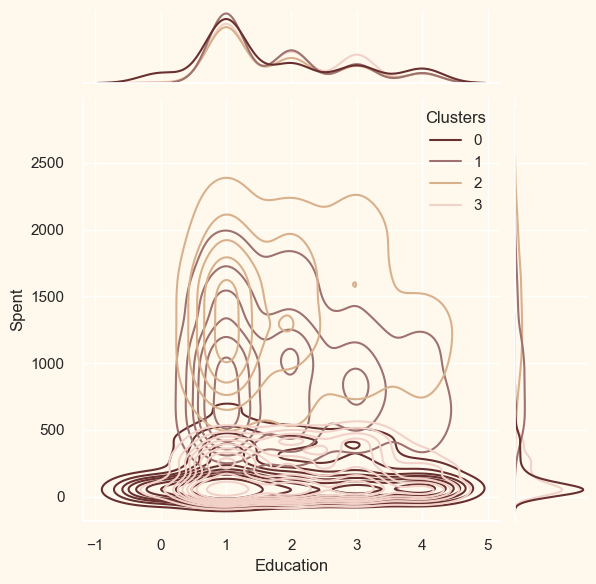

<Figure size 800x550 with 0 Axes>

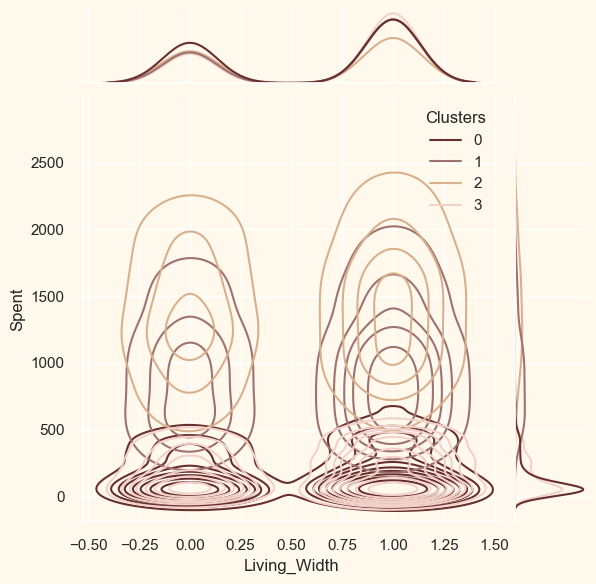

In [30]:
Personal = [
    "Kidhome",
    "Teenhome",
    "Customer_For",
    "Age",
    "Children",
    "Family_Size",
    "Is_Parent",
    "Education",
    "Living_Width"
]

for i in Personal: 
    plt.figure()
    sns.jointplot(x=data[i], y=data["Spent"], hue=data["Clusters"], kind="kde", palette=pal)
    plt.show()